# Intelligent Control (ECE-DK807)

## Electrical and Computer Engineering Department, University of Patras Greece

**Instructor:** Konstantinos Chazilygeroudis (costashatz@upatras.gr)

## Lab 3

### Gradient Descent

**Adam Optimizer**

1. Initialize $\boldsymbol{m}_0 = \boldsymbol{v}_0 = \boldsymbol{0}, \beta_1,\beta_2\in[0,1), \epsilon>0$
2. $\boldsymbol{g}_{k+1} = \nabla_{\boldsymbol{x}}f(\boldsymbol{x}_k)$
3. $\boldsymbol{m}_{k+1} = \beta_1\boldsymbol{m}_k + (1 - \beta_1)\boldsymbol{g}_{k+1}$
4. $\boldsymbol{v}_{k+1} = \beta_2\boldsymbol{v}_k + (1 - \beta_2)\boldsymbol{g}^2_{k+1}$
5. $\boldsymbol{x}_{k+1} = \boldsymbol{x}_k - \alpha\frac{\frac{\boldsymbol{m}_{k+1}}{1 - \beta_1^{k+1}}}{\sqrt{\frac{\boldsymbol{v}_{k+1}}{1 - \beta_2^{k+1}}}+\epsilon}$
6. $k=k+1$ and back to step 2 until we converge

Let's implement it!

In [58]:
# Let's first import modules
import numpy as np # Linear Algebra
import matplotlib.pyplot as plt # Plotting
import copy

In [59]:
# First we initialize values
adamM = 0.
adamV = 0.
adamB1n = 0.9
adamB2n = 0.999

def reset_adam():
    global adamM, adamV, adamB1n, adamB2n
    adamM = 0.
    adamV = 0.
    adamB1n = 0.9
    adamB2n = 0.999

# Adam step
# x is the current iterate, x_k
# df is the derivative/gradient of the function we want to optimize
# a is the learning rate
# b1 is the β_1 parameter
# b2 is the β_2 parameter
# eps is the ε parameter
def adam_step(x, df, a = 0.001, b1 = 0.9, b2 = 0.999, eps = 1e-8):
    global adamM, adamV, adamB1n, adamB2n
    ### TO-DO: Implement the steps (1-5) of the Adam algorithm. You need to return x_{k+1}
    ### adamM, adamV global variables are used to store the current m_k and v_k values (updated at each iteration)
    ### adamB1n, adamB2n global variables are used to store β_1^{k+1} and β_2^{k+1} (to avoid having to know the number of iterations)
    ### ANSWER: Insert code here
    # Evaluate the gradient function at x
    grad_value = df(x)
    # Step 1: Update biased first moment estimate
    adamM = b1 * adamM + (1 - b1) * grad_value
    # Step 2: Update biased second raw moment estimate
    adamV = b2 * adamV + (1 - b2) * (grad_value ** 2)
    # Step 3: Compute bias-corrected first moment estimate
    m_hat = adamM / (1 - adamB1n)
    # Step 4: Compute bias-corrected second raw moment estimate
    v_hat = adamV / (1 - adamB2n)
    # Step 5: Update parameters
    x_new = x - a * m_hat / (np.sqrt(v_hat) + eps)
    # Update the running powers for bias correction (simulating k = k+1)
    adamB1n = adamB1n * b1
    adamB2n = adamB2n * b2
    return x_new
    ### END of ANSWER

In [60]:
# First reset Adam
reset_adam()

def simple_f(x):
    return np.square(x)

def simple_df(x):
    return 2. * x

x = 10.
lr = 1e-3
x = adam_step(x, simple_df, lr)
assert(np.isclose(x, 9.999, rtol=1e-4))
x = adam_step(x, simple_df, lr)
assert(np.isclose(x, 9.998, rtol=1e-4))
x = adam_step(x, simple_df, lr)
assert(np.isclose(x, 9.997, rtol=1e-4))
x = adam_step(x, simple_df, lr)
assert(np.isclose(x, 9.996, rtol=1e-4))


reset_adam()

In [61]:
# Let's optimize the Rastrigin function
def f(x):
    ### TO-DO: Implement the Rastrigin function for any dimension as defined in https://www.sfu.ca/~ssurjano/rastr.html
    ### we assume that the input is of the form (dimensions, batch_size)
    ### f(x) should return a (batch_size,) numpy array
    ### ANSWER: Insert code here
    A = 10
    n = x.shape[0]
    return A * n + np.sum(x**2 - A * np.cos(2 * np.pi * x), axis=0)
    ### END of ANSWER

def df(x):
    ### TO-DO: Write the derivative of the Rastrigin function
    ### we assume that the input is of the form (dimensions, batch_size)
    ### df should return a (dimensions, batch_size) numpy array
    ### ANSWER: Insert code here
    A = 10
    return 2 * x + 2 * A * np.pi * np.sin(2 * np.pi * x)
    ### END of ANSWER

In [62]:
x = np.array([[5., 4., 3., 2., 1., 0., -1., -2., -3., -4., -5.]])
assert(np.isclose(f(x), np.array([25., 16., 9., 4., 1., 0., 1., 4., 9., 16., 25.])).all())


In [63]:
x = np.array([[5., 4., 3., 2., 1., 0., -1., -2., -3., -4., -5.]])
assert(np.isclose(df(x), np.array([[10., 8., 6., 4., 2., 0., -2., -4., -6., -8., -10.]])).all())


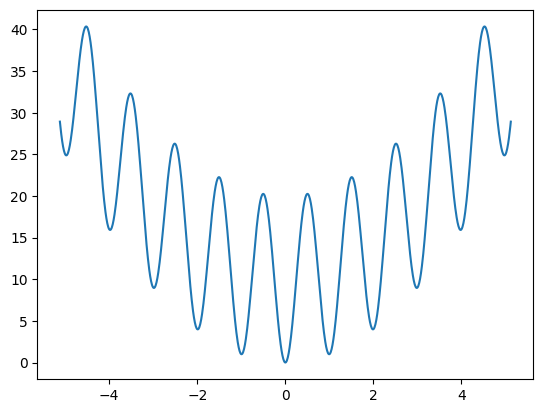

In [64]:
# Let's plot the function
x = np.linspace(-5.12, 5.12, 1000)

plt.close() # close previous
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(x, f(x.reshape((1, -1))));

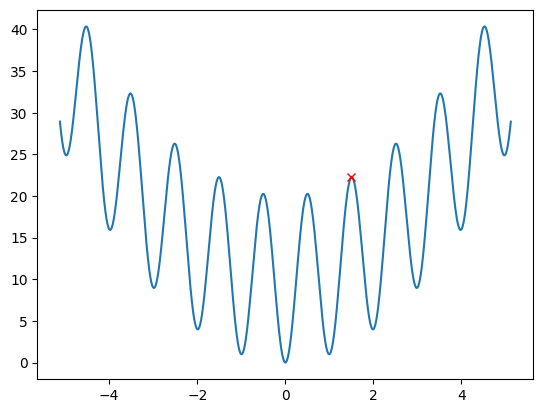

In [65]:
# Let's optimize
# Initial point!
x_init = np.array([[1.5]])

ax.plot(x_init, f(x_init), 'rx')

# Optimization!
x_new = np.copy(x_init)

fig # show figure again with updated point(s)

[[0.99127221]]


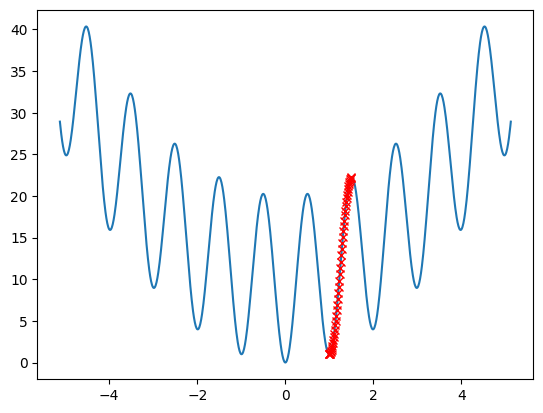

In [66]:
# Let's do a few steps of Adam
lr = 0.01 # learning rate
for i in range(50):
    x_new = adam_step(x_new, df, lr)
    ax.plot(x_new, f(x_new), 'rx')

print(x_new)

fig # show figure again with updated point(s)

### Neural Networks

Now let's learn a nice neural network to approximate our Rastrigin function!

First let's create a dataset. For this we sample $K$ points randomly in the input space of our function. The Rastrigin function is defined in $[-5.12, 5.12]$. So, let's do this:

In [67]:
# Number of points
K = 2000

np.random.seed(2)

### TO-DO: Sample random inputs in [-5.12, 5.12]. We need to sample a dim x K matrix. Store the result in a variable named 'Xn'
### ANSWER: Insert code here
Xn = np.random.uniform(-5.12, 5.12, size=(1, K))
### END of ANSWER

### TO-DO: Evaluate the function in the sampled points. Store the result in a output_dim x K matrix, and a variable named 'Yn'
### ANSWER: Insert code here
Yn = f(Xn)[None, :]
### END of ANSWER

In [68]:
assert(Xn.shape == (1, 2000))
assert(Yn.shape == (1, 2000))

assert(np.isclose(Xn[0, 0], -0.655, rtol=1e-3))
assert(np.isclose(Yn[0, 0], 16.029, rtol=1e-3))


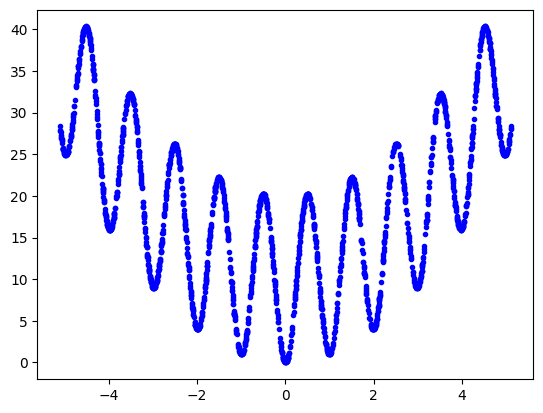

In [69]:
# Let's plot our dataset!
plt.close() # close previous
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(Xn, Yn, 'b.');

In [70]:
# Now let's import pytorch
import torch # For neural networks and automatic differentiation
torch.set_num_threads(1)

# Convert numpy arrays to tensors
# We transpose the arrays because torch assumes (batch_size, dimension)
X = torch.Tensor(Xn.T)
Y = torch.Tensor(Yn.T)

Now we need to make our neural network! Let's create a feedforward neural network with 2 hidden layers (32 and 64 units respectively), let's use `tanh` as the activation functions for the hidden layers, and no activation for the output layer!

In [71]:
# MLP Model
model = torch.nn.Sequential(
    ### TO-DO: Fill up the model with layers and activation functions as described above!
    ### ANSWER: Insert code here
    torch.nn.Linear(1, 32),
    torch.nn.Tanh(),
    torch.nn.Linear(32, 64),
    torch.nn.Tanh(),
    torch.nn.Linear(64, 1),
    ### END of ANSWER
)

In [72]:
params = list(model.named_parameters())
assert(params[0][1].size() == torch.Size([32, 1]))
assert(params[4][1].size() == torch.Size([1, 64]))


Now we need to make a learning loop:

1. Compute model prediction $y_{pred}$ for the input $X$
2. Compute loss given the actual labels $Y$
3. Zero the gradients of the optimizer
4. Automatically compute gradients (`backward` pass)
5. Perform one step of the optimizer

Let's implement those with the Adam optimizer!

In [73]:
# Let's first create a function that computes the predictions of the model
def prediction(model, x):
    ### TO-DO: Return the prediction of the model when given as input X
    ### ANSWER: Insert code here
    return model(x)
    ### END of ANSWER

In [74]:
# Now let's create a function that computes the mean squared error loss
def loss(y_pred, y_true):
    ### TO-DO: Compute and return the mean squared error. Remember that torch assumes (batch_size, dimension) for batched operations.
    ### ANSWER: Insert code here
    return torch.mean((y_pred - y_true) ** 2, dim=0)
    ### END of ANSWER

In [75]:
Y_perturbed = Y + 2.
assert(torch.isclose(loss(Y_perturbed, Y), torch.ones(Y.shape[1]) * 4.).all())
Y_perturbed = Y - 2.
assert(np.isclose(loss(Y_perturbed, Y), torch.ones(Y.shape[1]) * 4.).all())

assert(loss(Y_perturbed, Y).size() == torch.Size((1,)))

In [76]:
# Now let's create a function that performs steps 3, 4 and 5 of the above procedure. Assume that the loss value is given as input, and the optimizer is given as input
def update_optimizer(optimizer, loss_value):
    ### ANSWER: Insert code here
    # Step 3: Zero the gradients
    optimizer.zero_grad()
    # Step 4: Backward pass to compute gradients
    loss_value.backward()
    # Step 5: Perform one step of the optimizer
    optimizer.step()
    ### END of ANSWER

In [77]:
tmp_model = copy.deepcopy(model)

# Initialize weights of the model
def init_weights(m):
    if isinstance(m, torch.nn.Linear):
        m.weight.data.fill_(1.)
        m.bias.data.fill_(0.01)

tmp_model.apply(init_weights)

lr = 1e-3
optim = torch.optim.Adam(tmp_model.parameters(), lr=lr) # Adam optimizer

myloss = loss(prediction(tmp_model, X), Y)
assert(update_optimizer(optim, myloss) == None)
myloss = loss(prediction(tmp_model, X), Y)
assert(update_optimizer(optim, myloss) == None)

params = list(tmp_model.parameters())
assert(torch.isclose(params[0].grad, torch.ones_like(params[0].grad) * 0.9356, rtol=1e-4).all())
assert(torch.isclose(params[1].grad, torch.ones_like(params[1].grad) * 0.5833, rtol=1e-4).all())
assert(torch.isclose(params[2].grad, torch.ones_like(params[2].grad) * 0.0147, rtol=1e-4, atol=1e-4).all())
assert(torch.isclose(params[3].grad, torch.ones_like(params[3].grad) * 0.009, rtol=1e-4, atol=1e-4).all())
assert(torch.isclose(params[4].grad, torch.ones_like(params[4].grad) * 128.829, rtol=1e-4).all())
assert(torch.isclose(params[5].grad, torch.ones_like(params[5].grad) * (-44.53), rtol=1e-4).all())

In [78]:
# Let's create the optimizer
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) # Adam optimizer

for t in range(20000):
    y_pred = prediction(model, X)

    myloss = loss(y_pred, Y)
    if t == 0 or (t + 1) % 200 == 0:
        print(t+1, myloss.item() / K)

    update_optimizer(optimizer, myloss)

1 0.22407139587402344
200 0.058148403167724606
400 0.04889506530761719
600 0.030163911819458007
800 0.025712608337402344
1000 0.024914905548095702
1200 0.024722991943359376
1400 0.024633941650390626
1600 0.024573593139648436
1800 0.02451188659667969
2000 0.024418106079101564
2200 0.0242326602935791
2400 0.023845556259155274
2600 0.023289690017700194
2800 0.02269947624206543
3000 0.022053489685058592
3200 0.021308435440063476
3400 0.020375894546508788
3600 0.019078237533569336
3800 0.017694847106933594
4000 0.016266733169555663
4200 0.014763599395751953
4400 0.013341748237609863
4600 0.012068161964416504
4800 0.011144628524780273
5000 0.010396347999572755
5200 0.009690749168395995
5400 0.008991962432861328
5600 0.0079874267578125
5800 0.006623270511627197
6000 0.005193846225738525
6200 0.004026673793792725
6400 0.003324228048324585
6600 0.0028695805072784424
6800 0.002347105026245117
7000 0.001800233006477356
7200 0.001462194561958313
7400 0.0012461190223693847
7600 0.001097482919692993

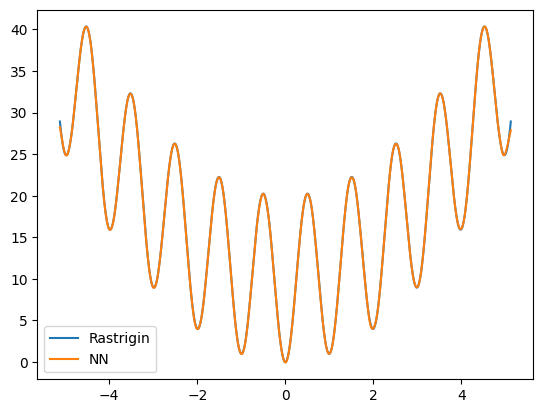

In [79]:
# Let's plot the function
x = np.linspace(-5.12, 5.12, 1000)

plt.close() # close previous
fig = plt.figure()
ax = fig.add_subplot(111)

# ax.plot(X, Y, '.')
ax.plot(x, f(x.reshape((1, -1))), label='Rastrigin')

ax.plot(x, [prediction(model, torch.Tensor(x[i].reshape((1, -1)))).detach().numpy()[0, 0] for i in range(len(x))], label='NN')

ax.legend();

In [80]:
# We can also create our model using the nn.Module class of pytorch
# The model should be identical to the previous one!
class MyModel(torch.nn.Module):
    # constructor
    def __init__(self):
        super().__init__()
        ### TO-DO: Create the 3 linear layers and store them in member variables
        ### ANSWER: Insert code here
        self.fc1 = torch.nn.Linear(1, 32)
        self.fc2 = torch.nn.Linear(32, 64)
        self.fc3 = torch.nn.Linear(64, 1)
        ### END of ANSWER

    # define forward pass
    def forward(self, x):
        ### TO-DO: Perform the forward pass of the neural network; we need to use `torch.nn.functional.tanh` to perform the desired activations
        ### ANSWER: Insert code here
        import torch.nn.functional as F
        x = self.fc1(x)
        x = F.tanh(x)
        x = self.fc2(x)
        x = F.tanh(x)
        x = self.fc3(x)
        ### END of ANSWER
        return x

In [83]:
tmp_model = MyModel()

# Initialize weights of the model
def init_weights(m):
    if isinstance(m, torch.nn.Linear):
        m.weight.data.fill_(1.)
        m.bias.data.fill_(0.01)

tmp_model.apply(init_weights)

lr = 1e-3
optim = torch.optim.Adam(tmp_model.parameters(), lr=lr) # Adam optimizer

myloss = loss(prediction(tmp_model, X), Y)
assert(update_optimizer(optim, myloss) == None)
myloss = loss(prediction(tmp_model, X), Y)
assert(update_optimizer(optim, myloss) == None)

params = list(tmp_model.parameters())
assert(torch.isclose(params[0].grad, torch.ones_like(params[0].grad) * 0.9356, rtol=1e-4).all())
assert(torch.isclose(params[1].grad, torch.ones_like(params[1].grad) * 0.5833, rtol=1e-4).all())
assert(torch.isclose(params[2].grad, torch.ones_like(params[2].grad) * 0.0147, rtol=1e-4, atol=1e-4).all())
assert(torch.isclose(params[3].grad, torch.ones_like(params[3].grad) * 0.009, rtol=1e-4, atol=1e-4).all())
assert(torch.isclose(params[4].grad, torch.ones_like(params[4].grad) * 128.829, rtol=1e-4).all())
assert(torch.isclose(params[5].grad, torch.ones_like(params[5].grad) * (-44.53), rtol=1e-4).all())

In [84]:
# Create the new model
model = MyModel()

# Let's create the optimizer
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) # Adam optimizer

for t in range(20000):
    y_pred = prediction(model, X)

    myloss = loss(y_pred, Y)
    if t == 0 or (t + 1) % 200 == 0:
        print(t+1, myloss.item() / K)

    update_optimizer(optimizer, myloss)

1 0.2271986541748047
200 0.058795120239257814
400 0.05102819061279297
600 0.04681218338012695
800 0.031230955123901366
1000 0.025803258895874023
1200 0.024909961700439454
1400 0.024687864303588866
1600 0.024581348419189453
1800 0.0245011043548584
2000 0.024404111862182616
2200 0.02425667381286621
2400 0.024016914367675782
2600 0.023649667739868162
2800 0.02316038131713867
3000 0.022596323013305664
3200 0.021883556365966797
3400 0.021113428115844726
3600 0.020207796096801758
3800 0.019288148880004883
4000 0.018327613830566407
4200 0.01722820281982422
4400 0.016135715484619142
4600 0.015107190132141114
4800 0.014002595901489258
5000 0.013118409156799316
5200 0.012355037689208984
5400 0.011775710105895997
5600 0.011299687385559082
5800 0.010906137466430665
6000 0.010592394828796387
6200 0.010330524444580078
6400 0.010086371421813964
6600 0.00947539520263672
6800 0.008550549507141113
7000 0.00771886682510376
7200 0.006797750473022461
7400 0.00619540548324585
7600 0.005678669452667236
7800 

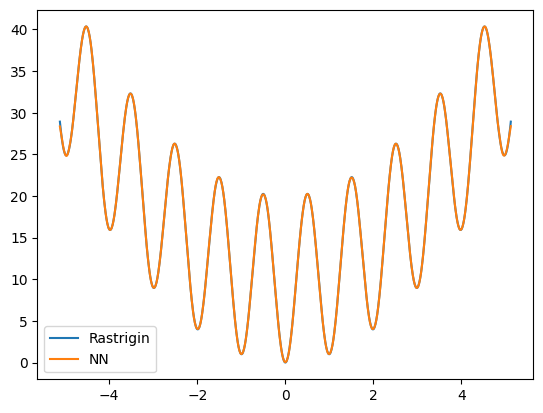

In [85]:
# Let's plot the function
x = np.linspace(-5.12, 5.12, 1000)

plt.close() # close previous
fig = plt.figure()
ax = fig.add_subplot(111)

# ax.plot(X, Y, '.')
ax.plot(x, f(x.reshape((1, -1))), label='Rastrigin')

ax.plot(x, [prediction(model, torch.Tensor(x[i].reshape((1, -1)))).detach().numpy()[0, 0] for i in range(len(x))], label='NN')

ax.legend();

In [86]:
# We can also use pytorch's built-in functions for learning with batches
from torch.utils.data import Dataset, DataLoader

# We create a custom dataset class
class NumpyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.Tensor(X) # Convert NumPy to Tensor
        self.y = torch.Tensor(y) # Convert NumPy to Tensor

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [87]:
# Let's create the actual dataset and dataloader (aka the worker that makes the batches)
dataset = NumpyDataset(Xn.T, Yn.T)

# We want a batch size of 32, and we randomly shuffle the samples
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

In [ ]:
# Create the new model
model = MyModel()

# Let's create the optimizer
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) # Adam optimizer

# Training Loop
num_epochs = 200
for epoch in range(num_epochs):
    epoch_loss = 0.0

    for batch_X, batch_y in dataloader:
        outputs = prediction(model, batch_X)

        myloss = loss(outputs, batch_y)

        update_optimizer(optimizer, myloss)

        epoch_loss += myloss.item()

    # if epoch == 0 or (epoch + 1) % 20 == 0:
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss/len(dataloader):.4f}")


Epoch 1/200, Loss: 259.7581
Epoch 2/200, Loss: 105.3233
Epoch 3/200, Loss: 94.0287
Epoch 4/200, Loss: 67.4894
Epoch 5/200, Loss: 55.6087
Epoch 6/200, Loss: 52.2266
Epoch 7/200, Loss: 50.8964
Epoch 8/200, Loss: 50.4322
Epoch 9/200, Loss: 50.2671
Epoch 10/200, Loss: 50.0876
Epoch 11/200, Loss: 50.0268
Epoch 12/200, Loss: 49.9156
Epoch 13/200, Loss: 49.8520
Epoch 14/200, Loss: 49.8620
Epoch 15/200, Loss: 49.9829
Epoch 16/200, Loss: 50.0881
Epoch 17/200, Loss: 49.9478
Epoch 18/200, Loss: 50.1013
Epoch 19/200, Loss: 49.7388
Epoch 20/200, Loss: 50.0385
Epoch 21/200, Loss: 49.8207
Epoch 22/200, Loss: 50.0136
Epoch 23/200, Loss: 49.9069
Epoch 24/200, Loss: 49.6741
Epoch 25/200, Loss: 49.8059
Epoch 26/200, Loss: 49.8389
Epoch 27/200, Loss: 49.7906
Epoch 28/200, Loss: 49.8124
Epoch 29/200, Loss: 50.0245
Epoch 30/200, Loss: 49.5791
Epoch 31/200, Loss: 49.8933
Epoch 32/200, Loss: 49.9725
Epoch 33/200, Loss: 49.7508
Epoch 34/200, Loss: 49.7234
Epoch 35/200, Loss: 49.7871
Epoch 36/200, Loss: 49.7458

In [ ]:
# Let's plot the function
x = np.linspace(-5.12, 5.12, 1000)

plt.close() # close previous
fig = plt.figure()
ax = fig.add_subplot(111)

# ax.plot(X, Y, '.')
ax.plot(x, f(x.reshape((1, -1))), label='Rastrigin')

ax.plot(x, [prediction(model, torch.Tensor(x[i].reshape((1, -1)))).detach().numpy()[0, 0] for i in range(len(x))], label='NN')

ax.legend();